# Poisson reconvolution fitting and validation

This notebook extends the reconvolution workflow introduced in
`08_naive_vs_reconvolution_fitting.ipynb`.

The previous notebook demonstrated that fitting a TCSPC histogram with an
unconvolved exponential can produce systematic lifetime bias when the
fluorescence lifetime becomes comparable to the instrument response function
(IRF) width.

Here we compare three fitting approaches applied to the same synthetic
Poisson-distributed TCSPC histogram:

1. naive unconvolved mono-exponential fitting using least squares;
2. mono-exponential reconvolution fitting using least squares;
3. mono-exponential reconvolution fitting using Poisson maximum likelihood.

The synthetic measurement follows

$$
N_i \sim \operatorname{Poisson}(\mu_i),
$$

where

$$
\mu(t)
=
A[\mathrm{IRF}_{\Delta t} * I_\tau](t) + B.
$$

The fitted reconvolution parameters are

$$
(A,\tau,B,\Delta t),
$$

while the IRF shape and width are treated as known.

The notebook therefore separates two related but distinct questions:

- how much bias is introduced by ignoring the IRF;
- how the statistical treatment changes when Poisson photon-counting
  likelihood is used instead of ordinary least squares.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tcspc_toolkit.convolution import convolve_decay_with_irf
from tcspc_toolkit.evaluation import (
    calculate_poisson_deviance_residuals,
    calculate_residuals,
    generate_fitted_signal,
)
from tcspc_toolkit.fitting import (
    fit_monoexponential_decay,
    fit_monoexponential_reconvolution,
    poisson_negative_log_likelihood,
)
from tcspc_toolkit.irf import (
    generate_gaussian_irf,
    normalize_irf,
    shift_irf,
)
from tcspc_toolkit.models import monoexponential_decay
from tcspc_toolkit.simulation import sample_photon_counts

## Measurement time axis

We use one uniformly spaced time grid for the ideal decay, IRF, convolution,
and measured TCSPC histogram.

The same grid convention is used as in the previous IRF and reconvolution
notebooks.

In [2]:
time = np.linspace(
    0.0,
    10.0,
    1001,
)

dt = time[1] - time[0]

print(f"Number of bins: {time.size}")
print(f"Bin width: {dt:.4f} ns")

Number of bins: 1001
Bin width: 0.0100 ns


## Instrument response function

A Gaussian IRF is generated and normalized to unit integrated area.

The IRF width is kept fixed throughout the fit. Only its temporal alignment
relative to the fluorescence decay will be estimated.

In [3]:
irf_centre = 1.0
irf_fwhm = 0.2

irf = generate_gaussian_irf(
    time=time,
    centre=irf_centre,
    fwhm=irf_fwhm,
    amplitude=1.0,
)

irf = normalize_irf(
    time=time,
    irf=irf,
)

irf_area = np.trapezoid(
    irf,
    x=time,
)

print(f"IRF FWHM: {irf_fwhm:.3f} ns")
print(f"Integrated IRF area: {irf_area:.6f}")

IRF FWHM: 0.200 ns
Integrated IRF area: 1.000000


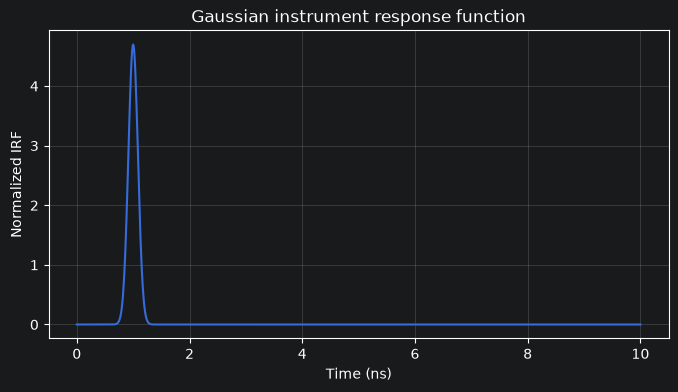

In [4]:
plt.figure(figsize=(8, 4))

plt.plot(
    time,
    irf,
)

plt.xlabel("Time (ns)")
plt.ylabel("Normalized IRF")
plt.title("Gaussian instrument response function")
plt.grid(alpha=0.3)

plt.show()

## Ground-truth TCSPC parameters

We choose a fluorescence lifetime that is comparable to the IRF width.

A non-zero temporal shift is also introduced so that the reconvolution fit
must recover both the fluorescence lifetime and the temporal alignment.

The ratio

$$
\frac{\mathrm{FWHM}_{\mathrm{IRF}}}{\tau}
$$

places the example in the regime where ignoring the IRF can noticeably bias
the recovered lifetime.

In [5]:
true_amplitude = 1_000_000.0
true_lifetime = 0.3
true_background = 20.0
true_temporal_shift = 0.18

irf_lifetime_ratio = (
    irf_fwhm / true_lifetime
)

print(f"True amplitude: {true_amplitude:.0f}")
print(f"True lifetime: {true_lifetime:.3f} ns")
print(f"True background: {true_background:.1f} counts/bin")
print(f"True temporal shift: {true_temporal_shift:.3f} ns")
print(
    "IRF FWHM / lifetime: "
    f"{irf_lifetime_ratio:.3f}"
)

True amplitude: 1000000
True lifetime: 0.300 ns
True background: 20.0 counts/bin
True temporal shift: 0.180 ns
IRF FWHM / lifetime: 0.667


## Construct the expected TCSPC histogram

The synthetic measurement is constructed explicitly from the physical forward
model.

First, an ideal mono-exponential fluorescence decay with unit amplitude and
zero background is generated:

$$
I_\tau(t) = \exp(-t/\tau).
$$

The normalized IRF is then shifted by the known ground-truth temporal offset
and convolved with the ideal decay.

Finally, the signal amplitude is applied and detector background is added:

$$
\mu(t)
=
A[\mathrm{IRF}_{\Delta t} * I_\tau](t)
+
B.
$$

Importantly, detector background is added after convolution.

In [6]:
ideal_decay = monoexponential_decay(
    time=time,
    amplitude=1.0,
    lifetime=true_lifetime,
    background=0.0,
)

shifted_irf = shift_irf(
    time=time,
    irf=irf,
    shift=true_temporal_shift,
)

convolved_decay = convolve_decay_with_irf(
    time=time,
    decay=ideal_decay,
    irf=shifted_irf,
)

expected_counts = (
    true_amplitude * convolved_decay
    + true_background
)

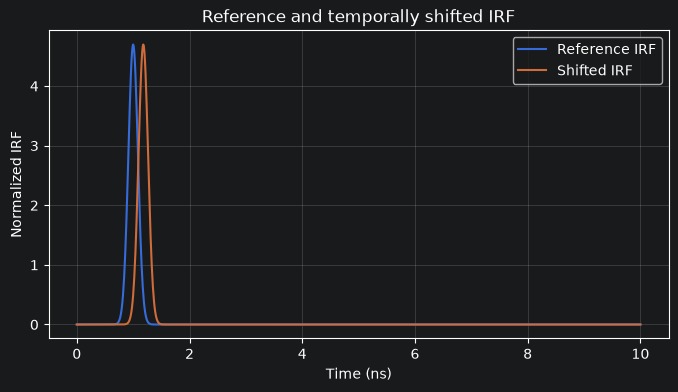

In [7]:
plt.figure(figsize=(8, 4))

plt.plot(
    time,
    irf,
    label="Reference IRF",
)

plt.plot(
    time,
    shifted_irf,
    label="Shifted IRF",
)

plt.xlabel("Time (ns)")
plt.ylabel("Normalized IRF")
plt.title("Reference and temporally shifted IRF")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [8]:
reference_peak_time = time[
    np.argmax(irf)
]

shifted_peak_time = time[
    np.argmax(shifted_irf)
]

print(
    f"Reference IRF peak: "
    f"{reference_peak_time:.3f} ns"
)
print(
    f"Shifted IRF peak: "
    f"{shifted_peak_time:.3f} ns"
)
print(
    f"Observed peak displacement: "
    f"{shifted_peak_time - reference_peak_time:.3f} ns"
)

Reference IRF peak: 1.000 ns
Shifted IRF peak: 1.180 ns
Observed peak displacement: 0.180 ns


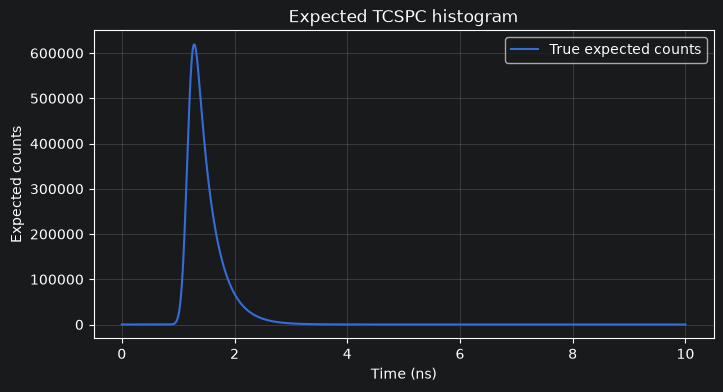

In [9]:
plt.figure(figsize=(8, 4))

plt.plot(
    time,
    expected_counts,
    label="True expected counts",
)

plt.xlabel("Time (ns)")
plt.ylabel("Expected counts")
plt.title("Expected TCSPC histogram")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [10]:
print(
    f"Minimum expected count: "
    f"{expected_counts.min():.3f}"
)
print(
    f"Maximum expected count: "
    f"{expected_counts.max():.1f}"
)

Minimum expected count: 20.000
Maximum expected count: 618987.8


## Poisson sampling

A TCSPC measurement does not return the deterministic expectation directly.

Instead, the photon count in every histogram bin is sampled independently
according to

$$
N_i \sim \operatorname{Poisson}(\mu_i).
$$

A fixed random seed is used so that the notebook remains reproducible.

In [11]:
rng = np.random.default_rng(42)

measured_counts = sample_photon_counts(
    expected_counts=expected_counts,
    rng=rng,
)

print(f"Total detected photons: {measured_counts.sum():,}")
print(f"Maximum measured count: {measured_counts.max():,}")
print(
    f"Number of zero-count bins: "
    f"{np.count_nonzero(measured_counts == 0)}"
)

Total detected photons: 30,523,066
Maximum measured count: 618,686
Number of zero-count bins: 0


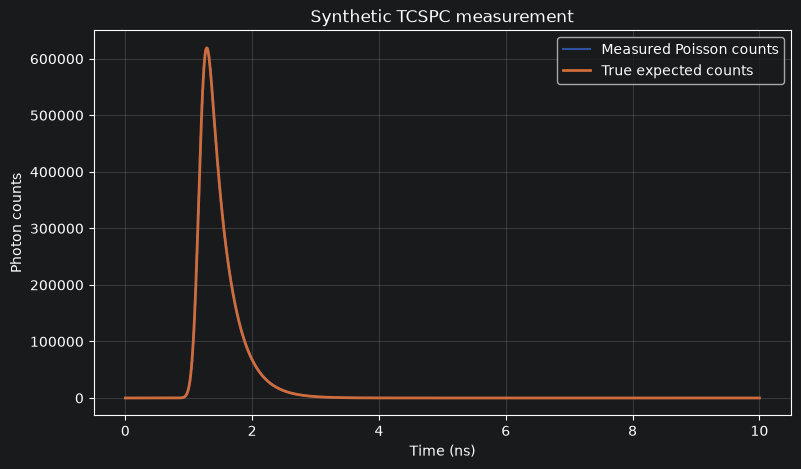

In [12]:
plt.figure(figsize=(9, 5))

plt.step(
    time,
    measured_counts,
    where="mid",
    label="Measured Poisson counts",
    alpha=0.7,
)

plt.plot(
    time,
    expected_counts,
    label="True expected counts",
    linewidth=2,
)

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts")
plt.title("Synthetic TCSPC measurement")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Naive unconvolved least-squares fit

The first fit deliberately ignores the IRF.

As in the previous notebook, the naive mono-exponential fit starts at the
maximum of the measured TCSPC histogram. The time axis is reset so that the
observed histogram peak corresponds to zero:

$$
t' = t - t_{\mathrm{peak}}.
$$

Only the decay tail from the measured peak onward is fitted.

This provides a more meaningful naive baseline than attempting to fit the
pre-peak region with a monotonically decreasing exponential.

In [13]:
peak_index = int(
    np.argmax(measured_counts)
)

peak_time = time[peak_index]

naive_time = (
    time[peak_index:]
    - peak_time
)

naive_counts = measured_counts[
    peak_index:
]

background_guess = float(
    np.median(naive_counts[-100:])
)

amplitude_guess = max(
    float(naive_counts[0])
    - background_guess,
    1.0,
)

print(f"Measured peak time: {peak_time:.3f} ns")
print(f"Naive fit bins: {naive_time.size}")
print(
    f"Initial amplitude guess: "
    f"{amplitude_guess:.1f}"
)
print(
    f"Initial background guess: "
    f"{background_guess:.1f}"
)

Measured peak time: 1.290 ns
Naive fit bins: 872
Initial amplitude guess: 618667.0
Initial background guess: 19.0


The naive model is

$$
I(t') = A\exp(-t'/\tau) + B.
$$

Because the model does not include the IRF, its fitted amplitude refers to the
start of the selected decay tail rather than to the amplitude parameter of the
full reconvolution forward model.

The lifetime estimate is therefore the main quantity of interest in this
comparison.

In [14]:
naive_result = fit_monoexponential_decay(
    time=naive_time,
    counts=naive_counts,
    initial_guess=(
        amplitude_guess,
        1.0,
        background_guess,
    ),
)

naive_fitted_counts = generate_fitted_signal(
    time=naive_time,
    fit_result=naive_result,
)

naive_relative_lifetime_error = (
    naive_result.lifetime
    - true_lifetime
) / true_lifetime

print(
    f"Naive fitted lifetime: "
    f"{naive_result.lifetime:.6f} ns"
)
print(
    f"Naive fitted background: "
    f"{naive_result.background:.3f}"
)
print(
    "Relative lifetime error: "
    f"{100 * naive_relative_lifetime_error:.2f}%"
)

Naive fitted lifetime: 0.317533 ns
Naive fitted background: 0.000
Relative lifetime error: 5.84%


## Least-squares reconvolution fit

The reconvolution model now uses the complete measured histogram and explicitly
includes the known IRF.

The fitted parameters are

$$
(A,\tau,B,\Delta t).
$$

A data-derived initial amplitude is estimated by comparing the total
background-subtracted photon count with a unit-amplitude convolved decay.

The naive lifetime estimate is used only as an optimizer starting value.

In [15]:
initial_decay = monoexponential_decay(
    time=time,
    amplitude=1.0,
    lifetime=naive_result.lifetime,
    background=0.0,
)

initial_convolved = convolve_decay_with_irf(
    time=time,
    decay=initial_decay,
    irf=irf,
)

estimated_signal_counts = max(
    float(measured_counts.sum())
    - background_guess * measured_counts.size,
    1.0,
)

reconvolution_amplitude_guess = (
    estimated_signal_counts
    / initial_convolved.sum()
)

reconvolution_initial_guess = (
    reconvolution_amplitude_guess,
    naive_result.lifetime,
    background_guess,
    0.0,
)

temporal_shift_bounds = (
    -0.5,
    0.5,
)

print(
    f"Reconvolution amplitude guess: "
    f"{reconvolution_amplitude_guess:.1f}"
)
print(
    f"Reconvolution lifetime guess: "
    f"{naive_result.lifetime:.6f} ns"
)
print(
    f"Reconvolution background guess: "
    f"{background_guess:.1f}"
)
print(
    "Reconvolution temporal-shift guess: "
    "0.000 ns"
)

Reconvolution amplitude guess: 945688.2
Reconvolution lifetime guess: 0.317533 ns
Reconvolution background guess: 19.0
Reconvolution temporal-shift guess: 0.000 ns


In [16]:
least_squares_result = (
    fit_monoexponential_reconvolution(
        time=time,
        counts=measured_counts,
        irf=irf,
        initial_guess=reconvolution_initial_guess,
        temporal_shift_bounds=temporal_shift_bounds,
        objective="least_squares",
    )
)

least_squares_relative_lifetime_error = (
    least_squares_result.lifetime
    - true_lifetime
) / true_lifetime

print(
    f"Optimization successful: "
    f"{least_squares_result.success}"
)
print(
    f"Fitted amplitude: "
    f"{least_squares_result.amplitude:.1f}"
)
print(
    f"Fitted lifetime: "
    f"{least_squares_result.lifetime:.6f} ns"
)
print(
    f"Fitted background: "
    f"{least_squares_result.background:.3f}"
)
print(
    f"Fitted temporal shift: "
    f"{least_squares_result.temporal_shift:.6f} ns"
)
print(
    "Relative lifetime error: "
    f"{100 * least_squares_relative_lifetime_error:.3f}%"
)

Optimization successful: True
Fitted amplitude: 1000440.6
Fitted lifetime: 0.299885 ns
Fitted background: 18.337
Fitted temporal shift: 0.180047 ns
Relative lifetime error: -0.038%


## Poisson maximum-likelihood reconvolution fit

The same physical reconvolution model is now fitted using the Poisson
negative log-likelihood,

$$
-\log L
=
\sum_i
\left[
\mu_i - N_i\log(\mu_i)
\right],
$$

up to an additive constant independent of the fitted parameters.

The least-squares reconvolution solution is used as the initial point for the
Poisson optimization. This separates the statistical objective from
unnecessary differences in optimizer initialization.

In [17]:
poisson_initial_guess = (
    least_squares_result.amplitude,
    least_squares_result.lifetime,
    least_squares_result.background,
    least_squares_result.temporal_shift,
)

poisson_result = (
    fit_monoexponential_reconvolution(
        time=time,
        counts=measured_counts,
        irf=irf,
        initial_guess=poisson_initial_guess,
        temporal_shift_bounds=temporal_shift_bounds,
        objective="poisson",
    )
)

poisson_relative_lifetime_error = (
    poisson_result.lifetime
    - true_lifetime
) / true_lifetime

print(
    f"Optimization successful: "
    f"{poisson_result.success}"
)
print(
    f"Fitted amplitude: "
    f"{poisson_result.amplitude:.1f}"
)
print(
    f"Fitted lifetime: "
    f"{poisson_result.lifetime:.6f} ns"
)
print(
    f"Fitted background: "
    f"{poisson_result.background:.3f}"
)
print(
    f"Fitted temporal shift: "
    f"{poisson_result.temporal_shift:.6f} ns"
)
print(
    "Relative lifetime error: "
    f"{100 * poisson_relative_lifetime_error:.3f}%"
)

Optimization successful: True
Fitted amplitude: 1000440.6
Fitted lifetime: 0.299900 ns
Fitted background: 18.337
Fitted temporal shift: 0.180047 ns
Relative lifetime error: -0.033%


In [18]:
fit_comparison = pd.DataFrame(
    {
        "True": [
            true_amplitude,
            true_lifetime,
            true_background,
            true_temporal_shift,
        ],
        "Naive LS": [
            naive_result.amplitude,
            naive_result.lifetime,
            naive_result.background,
            np.nan,
        ],
        "Reconvolution LS": [
            least_squares_result.amplitude,
            least_squares_result.lifetime,
            least_squares_result.background,
            least_squares_result.temporal_shift,
        ],
        "Reconvolution Poisson": [
            poisson_result.amplitude,
            poisson_result.lifetime,
            poisson_result.background,
            poisson_result.temporal_shift,
        ],
    },
    index=[
        "Amplitude",
        "Lifetime (ns)",
        "Background (counts/bin)",
        "Temporal shift (ns)",
    ],
)

fit_comparison

,True,Naive LS,Reconvolution LS,Reconvolution Poisson
Amplitude,1000000.00,6.767406e+05,1.000441e+06,1.000441e+06
Lifetime (ns),0.30,3.175330e-01,2.998850e-01,2.998999e-01
Background (counts/bin),20.00,2.336646e-13,1.833658e+01,1.833658e+01
Temporal shift (ns),0.18,NaN,1.800474e-01,1.800474e-01


In [19]:
lifetime_comparison = pd.DataFrame(
    {
        "Method": [
            "Naive LS",
            "Reconvolution LS",
            "Reconvolution Poisson",
        ],
        "Lifetime (ns)": [
            naive_result.lifetime,
            least_squares_result.lifetime,
            poisson_result.lifetime,
        ],
        "Signed relative error (%)": [
            100 * naive_relative_lifetime_error,
            100 * least_squares_relative_lifetime_error,
            100 * poisson_relative_lifetime_error,
        ],
    }
)

lifetime_comparison

,Method,Lifetime (ns),Signed relative error (%)
0,Naive LS,0.317533,5.844337
1,Reconvolution LS,0.299885,-0.038336
2,Reconvolution Poisson,0.299900,-0.033371


## Comparison of fitted curves

The three fitted models are now compared with the same measured TCSPC
histogram and the known ground-truth expectation.

The naive exponential was fitted only from the measured histogram maximum
onward. Its fitted curve is therefore shown only over that fitting interval.

The reconvolution models describe the complete TCSPC histogram, including the
IRF-dominated leading edge.

In [20]:
naive_fitted_full = np.full(
    time.shape,
    np.nan,
    dtype=np.float64,
)

naive_fitted_full[peak_index:] = (
    naive_fitted_counts
)

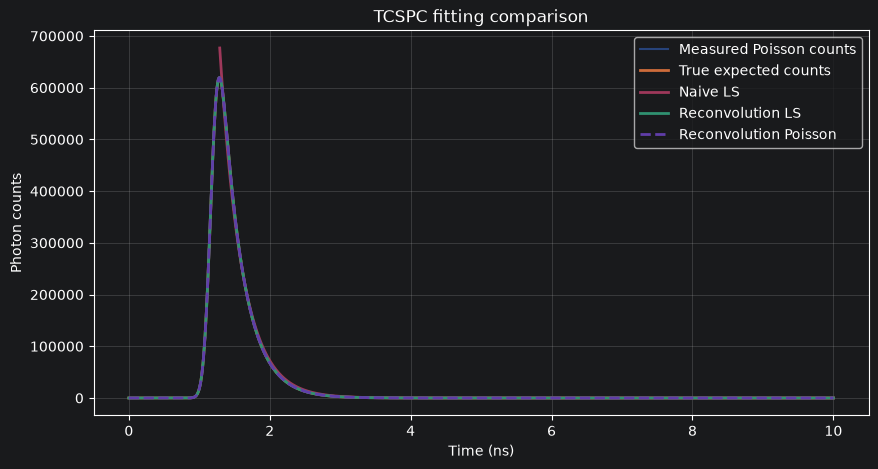

In [21]:
plt.figure(figsize=(10, 5))

plt.step(
    time,
    measured_counts,
    where="mid",
    label="Measured Poisson counts",
    alpha=0.5,
)

plt.plot(
    time,
    expected_counts,
    label="True expected counts",
    linewidth=2,
)

plt.plot(
    time,
    naive_fitted_full,
    label="Naive LS",
    linewidth=2,
)

plt.plot(
    time,
    least_squares_result.fitted_curve,
    label="Reconvolution LS",
    linewidth=2,
)

plt.plot(
    time,
    poisson_result.fitted_curve,
    label="Reconvolution Poisson",
    linewidth=2,
    linestyle="--",
)

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts")
plt.title("TCSPC fitting comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

A logarithmic count scale makes the decay tail and detector-background region
easier to inspect.

Because the measured histogram contains strictly non-negative discrete photon
counts, only positive measured bins should contribute directly to a logarithmic
visualization. In the present high-count example the non-zero background makes
this straightforward.

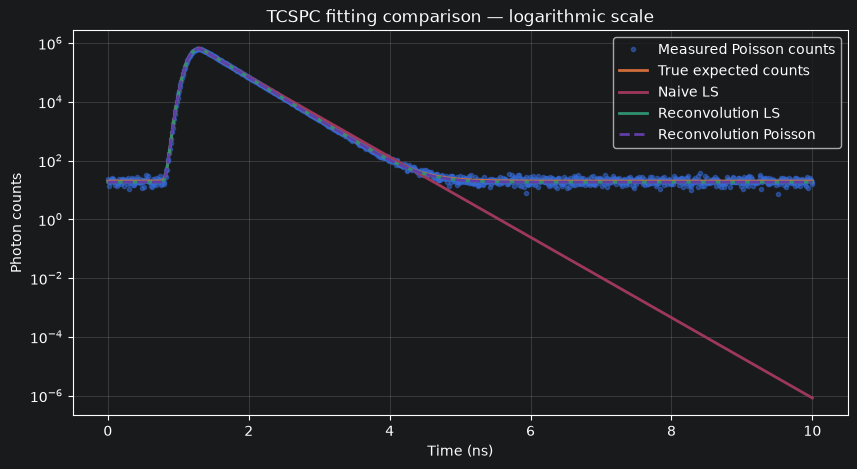

In [22]:
plt.figure(figsize=(10, 5))

plt.semilogy(
    time,
    measured_counts,
    ".",
    label="Measured Poisson counts",
    alpha=0.5,
)

plt.semilogy(
    time,
    expected_counts,
    label="True expected counts",
    linewidth=2,
)

plt.semilogy(
    time,
    naive_fitted_full,
    label="Naive LS",
    linewidth=2,
)

plt.semilogy(
    time,
    least_squares_result.fitted_curve,
    label="Reconvolution LS",
    linewidth=2,
)

plt.semilogy(
    time,
    poisson_result.fitted_curve,
    label="Reconvolution Poisson",
    linewidth=2,
    linestyle="--",
)

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts")
plt.title("TCSPC fitting comparison — logarithmic scale")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Raw residual diagnostics

Raw residuals are defined as

$$
r_i = N_i - \mu_i.
$$

A well-specified model should leave fluctuations around zero without strong
systematic structure.

Because the naive exponential was fitted only from the measured histogram peak
onward, its residuals are evaluated only over that same interval.

In [23]:
naive_raw_residuals = calculate_residuals(
    observed=naive_counts,
    fitted=naive_fitted_counts,
)

least_squares_raw_residuals = (
    calculate_residuals(
        observed=measured_counts,
        fitted=least_squares_result.fitted_curve,
    )
)

poisson_raw_residuals = (
    calculate_residuals(
        observed=measured_counts,
        fitted=poisson_result.fitted_curve,
    )
)

In [24]:
naive_raw_residuals_full = np.full(
    time.shape,
    np.nan,
    dtype=np.float64,
)

naive_raw_residuals_full[peak_index:] = (
    naive_raw_residuals
)

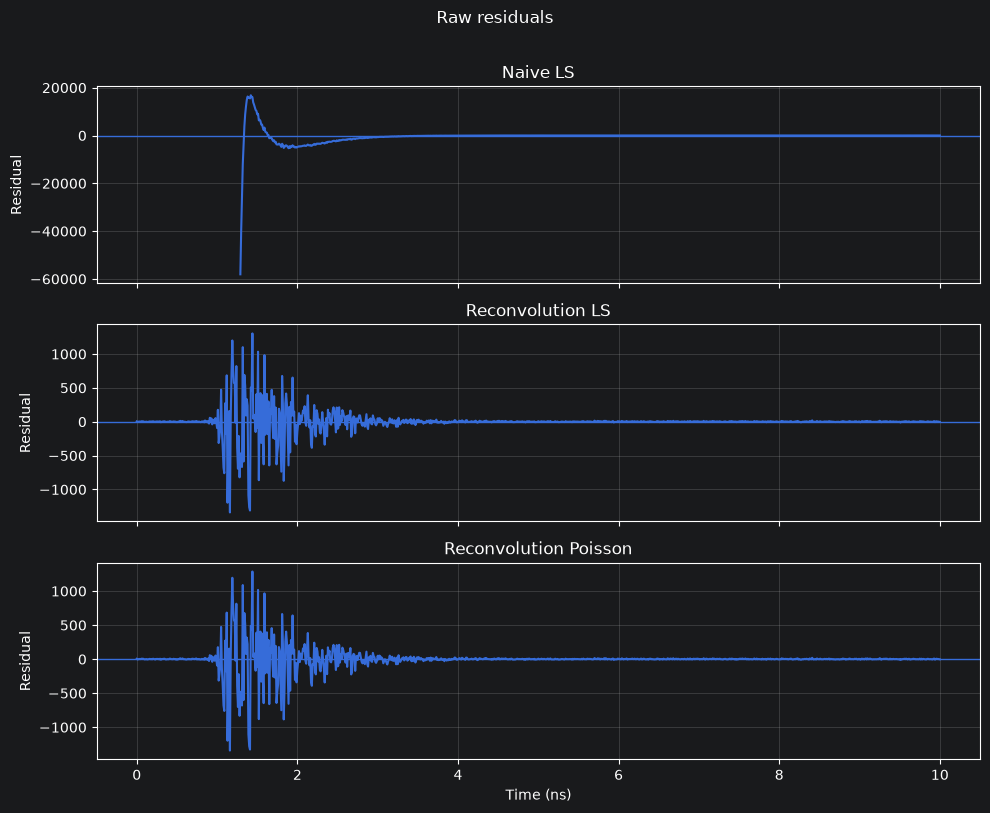

In [25]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 8),
    sharex=True,
)

axes[0].plot(
    time,
    naive_raw_residuals_full,
)

axes[0].axhline(
    0.0,
    linewidth=1,
)

axes[0].set_ylabel("Residual")
axes[0].set_title("Naive LS")

axes[1].plot(
    time,
    least_squares_raw_residuals,
)

axes[1].axhline(
    0.0,
    linewidth=1,
)

axes[1].set_ylabel("Residual")
axes[1].set_title("Reconvolution LS")

axes[2].plot(
    time,
    poisson_raw_residuals,
)

axes[2].axhline(
    0.0,
    linewidth=1,
)

axes[2].set_xlabel("Time (ns)")
axes[2].set_ylabel("Residual")
axes[2].set_title("Reconvolution Poisson")

for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(
    "Raw residuals",
    y=1.01,
)

plt.tight_layout()
plt.show()

## Poisson deviance residuals

Raw residuals do not account for the count-dependent variance of Poisson data.

For a Poisson model, the signed deviance residual is

$$
r_i^{(D)}
=
\operatorname{sign}(N_i-\mu_i)
\sqrt{
2
\left[
N_i\log\left(\frac{N_i}{\mu_i}\right)
-
(N_i-\mu_i)
\right]
}.
$$

For zero observed counts, the expression is evaluated using its appropriate
Poisson limit.

Unlike raw residuals, deviance residuals account for the statistical scale of
the expected photon count in each bin.

In [26]:
naive_deviance_residuals = (
    calculate_poisson_deviance_residuals(
        observed=naive_counts,
        expected=naive_fitted_counts,
    )
)

least_squares_deviance_residuals = (
    calculate_poisson_deviance_residuals(
        observed=measured_counts,
        expected=least_squares_result.fitted_curve,
    )
)

poisson_deviance_residuals = (
    calculate_poisson_deviance_residuals(
        observed=measured_counts,
        expected=poisson_result.fitted_curve,
    )
)

In [27]:
naive_deviance_residuals_full = np.full(
    time.shape,
    np.nan,
    dtype=np.float64,
)

naive_deviance_residuals_full[
    peak_index:
] = naive_deviance_residuals

In [28]:
print(
    f"Minimum naive fitted expectation: "
    f"{naive_fitted_counts.min():.6e}"
)

Minimum naive fitted expectation: 8.272364e-07


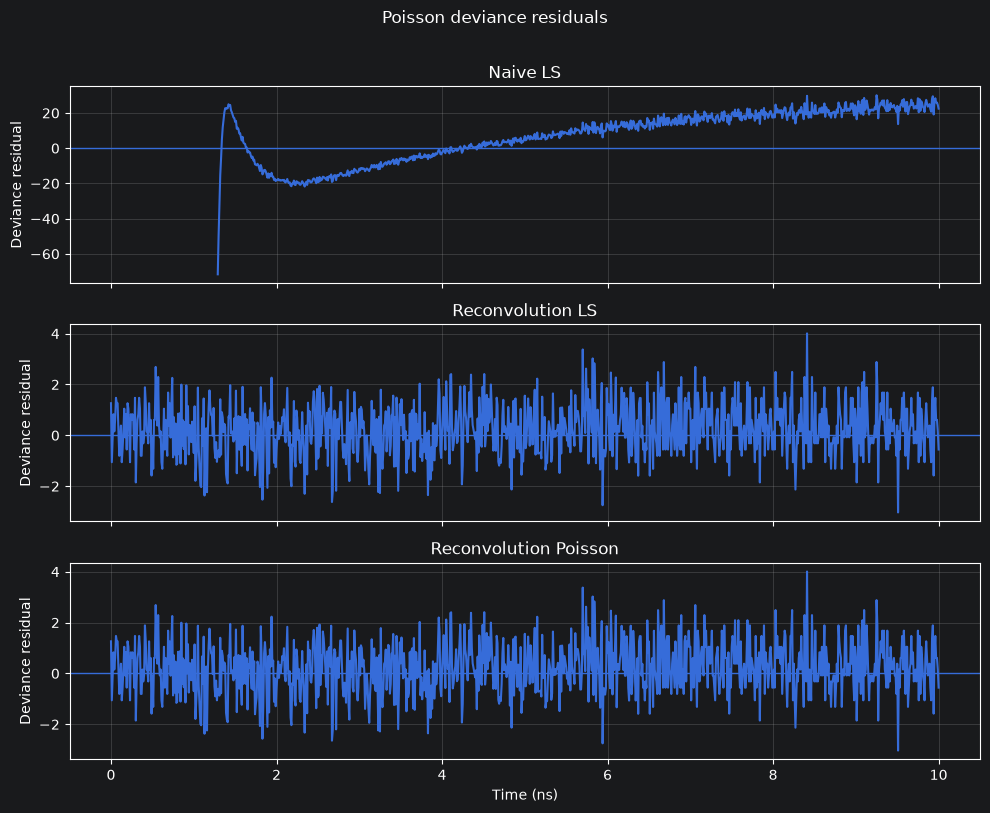

In [29]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 8),
    sharex=True,
)

axes[0].plot(
    time,
    naive_deviance_residuals_full,
)

axes[0].axhline(
    0.0,
    linewidth=1,
)

axes[0].set_ylabel("Deviance residual")
axes[0].set_title("Naive LS")

axes[1].plot(
    time,
    least_squares_deviance_residuals,
)

axes[1].axhline(
    0.0,
    linewidth=1,
)

axes[1].set_ylabel("Deviance residual")
axes[1].set_title("Reconvolution LS")

axes[2].plot(
    time,
    poisson_deviance_residuals,
)

axes[2].axhline(
    0.0,
    linewidth=1,
)

axes[2].set_xlabel("Time (ns)")
axes[2].set_ylabel("Deviance residual")
axes[2].set_title("Reconvolution Poisson")

for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(
    "Poisson deviance residuals",
    y=1.01,
)

plt.tight_layout()
plt.show()

In [30]:
residual_summary = pd.DataFrame(
    {
        "Method": [
            "Naive LS",
            "Reconvolution LS",
            "Reconvolution Poisson",
        ],
        "Mean deviance residual": [
            np.mean(naive_deviance_residuals),
            np.mean(
                least_squares_deviance_residuals
            ),
            np.mean(
                poisson_deviance_residuals
            ),
        ],
        "RMS deviance residual": [
            np.sqrt(
                np.mean(
                    naive_deviance_residuals**2
                )
            ),
            np.sqrt(
                np.mean(
                    least_squares_deviance_residuals**2
                )
            ),
            np.sqrt(
                np.mean(
                    poisson_deviance_residuals**2
                )
            ),
        ],
    }
)

residual_summary

,Method,Mean deviance residual,RMS deviance residual
0,Naive LS,7.021661,16.008578
1,Reconvolution LS,0.229728,1.052404
2,Reconvolution Poisson,0.223926,1.052337


## Poisson likelihood comparison

The least-squares and Poisson reconvolution fits use exactly the same forward
model and the same observed histogram. They differ only in the optimization
objective.

We can therefore evaluate the Poisson negative log-likelihood for both fitted
curves directly.

The Poisson-MLE solution should achieve a Poisson NLL no larger than the
least-squares solution, up to numerical optimizer tolerance.

In [31]:
least_squares_poisson_nll = (
    poisson_negative_log_likelihood(
        observed=measured_counts,
        expected=least_squares_result.fitted_curve,
    )
)

poisson_fit_nll = (
    poisson_negative_log_likelihood(
        observed=measured_counts,
        expected=poisson_result.fitted_curve,
    )
)

nll_difference = (
    least_squares_poisson_nll
    - poisson_fit_nll
)

print(
    "Poisson NLL at LS reconvolution solution: "
    f"{least_squares_poisson_nll:.6f}"
)
print(
    "Poisson NLL at Poisson-MLE solution: "
    f"{poisson_fit_nll:.6f}"
)
print(
    "NLL improvement (LS - Poisson): "
    f"{nll_difference:.6f}"
)

Poisson NLL at LS reconvolution solution: -353691602.490766
Poisson NLL at Poisson-MLE solution: -353691602.562114
NLL improvement (LS - Poisson): 0.071348


## Lifetime dependence of fitting bias

The previous comparison considered one high-count TCSPC histogram with

$$
\tau = 0.3\ \mathrm{ns}
$$

and demonstrated that reconvolution removes most of the lifetime bias produced
by the naive unconvolved model.

We now extend the systematic experiment from
`08_naive_vs_reconvolution_fitting.ipynb`.

The Gaussian IRF width remains fixed while the fluorescence lifetime is varied.
The relevant dimensionless ratio is

$$
\frac{\tau}{\mathrm{FWHM}_{\mathrm{IRF}}}.
$$

Three fitting methods are compared for every synthetic histogram:

1. naive unconvolved least squares;
2. least-squares reconvolution;
3. Poisson maximum-likelihood reconvolution.

To isolate the effect of lifetime relative to IRF width, the true temporal shift
is set to zero throughout this experiment.

The expected number of fluorescence signal photons is also kept approximately
constant for all lifetimes. This prevents longer-lifetime curves from receiving
more photons simply because their integrated decay is larger.

In [32]:
sweep_ratios = np.array([
    0.25,
    0.5,
    0.75,
    1.0,
    1.5,
    2.0,
    3.0,
    5.0,
    10.0,
    20.0,
])

sweep_lifetimes = (
    sweep_ratios * irf_fwhm
)

sweep_target_signal_photons = 100_000
sweep_background = 2.0

sweep_table = pd.DataFrame(
    {
        "tau_over_fwhm": sweep_ratios,
        "lifetime_ns": sweep_lifetimes,
    }
)

sweep_table

,tau_over_fwhm,lifetime_ns
0,0.25,0.05
1,0.50,0.10
2,0.75,0.15
3,1.00,0.20
4,1.50,0.30
5,2.00,0.40
6,3.00,0.60
7,5.00,1.00
8,10.00,2.00
9,20.00,4.00


For every true lifetime, the following workflow is repeated:

1. generate a unit-amplitude mono-exponential decay;
2. convolve it with the fixed normalized IRF;
3. scale the convolved signal to a fixed total number of expected signal
   photons;
4. add a fixed detector background;
5. generate one Poisson realization;
6. fit the post-peak tail with the naive exponential;
7. fit the complete histogram using least-squares reconvolution;
8. use the least-squares solution to initialize Poisson-MLE reconvolution.

All three methods therefore operate on the same Poisson realization for each
true lifetime.

In [33]:
def compare_three_fits(
    true_lifetime: float,
    rng: np.random.Generator,
) -> dict[str, float | bool]:
    unit_decay = monoexponential_decay(
        time=time,
        amplitude=1.0,
        lifetime=true_lifetime,
        background=0.0,
    )

    unit_convolved = convolve_decay_with_irf(
        time=time,
        decay=unit_decay,
        irf=irf,
    )

    amplitude = (
        sweep_target_signal_photons
        / unit_convolved.sum()
    )

    expected_counts = (
        amplitude * unit_convolved
        + sweep_background
    )

    measured_counts = sample_photon_counts(
        expected_counts=expected_counts,
        rng=rng,
    )

    # Naive post-peak least-squares fit
    peak_index = int(
        np.argmax(measured_counts)
    )

    naive_time = (
        time[peak_index:]
        - time[peak_index]
    )

    naive_counts = measured_counts[
        peak_index:
    ]

    background_guess = float(
        np.median(naive_counts[-100:])
    )

    amplitude_guess = max(
        float(naive_counts[0])
        - background_guess,
        1.0,
    )

    naive_result = fit_monoexponential_decay(
        time=naive_time,
        counts=naive_counts,
        initial_guess=(
            amplitude_guess,
            1.0,
            background_guess,
        ),
    )

    # Data-derived reconvolution amplitude guess
    initial_decay = monoexponential_decay(
        time=time,
        amplitude=1.0,
        lifetime=naive_result.lifetime,
        background=0.0,
    )

    initial_convolved = (
        convolve_decay_with_irf(
            time=time,
            decay=initial_decay,
            irf=irf,
        )
    )

    estimated_signal_counts = max(
        float(measured_counts.sum())
        - background_guess
        * measured_counts.size,
        1.0,
    )

    reconvolution_amplitude_guess = (
        estimated_signal_counts
        / initial_convolved.sum()
    )

    reconvolution_initial_guess = (
        reconvolution_amplitude_guess,
        naive_result.lifetime,
        background_guess,
        0.0,
    )

    least_squares_result = (
        fit_monoexponential_reconvolution(
            time=time,
            counts=measured_counts,
            irf=irf,
            initial_guess=(
                reconvolution_initial_guess
            ),
            temporal_shift_bounds=(
                -0.5,
                0.5,
            ),
            objective="least_squares",
        )
    )

    # Use LS reconvolution as the initial point for MLE
    poisson_result = (
        fit_monoexponential_reconvolution(
            time=time,
            counts=measured_counts,
            irf=irf,
            initial_guess=(
                least_squares_result.amplitude,
                least_squares_result.lifetime,
                least_squares_result.background,
                least_squares_result.temporal_shift,
            ),
            temporal_shift_bounds=(
                -0.5,
                0.5,
            ),
            objective="poisson",
        )
    )

    naive_relative_error = (
        naive_result.lifetime
        - true_lifetime
    ) / true_lifetime

    least_squares_relative_error = (
        least_squares_result.lifetime
        - true_lifetime
    ) / true_lifetime

    poisson_relative_error = (
        poisson_result.lifetime
        - true_lifetime
    ) / true_lifetime

    return {
        "true_lifetime": true_lifetime,
        "tau_over_fwhm": (
            true_lifetime / irf_fwhm
        ),
        "naive_lifetime": (
            naive_result.lifetime
        ),
        "least_squares_lifetime": (
            least_squares_result.lifetime
        ),
        "poisson_lifetime": (
            poisson_result.lifetime
        ),
        "naive_relative_error": (
            naive_relative_error
        ),
        "least_squares_relative_error": (
            least_squares_relative_error
        ),
        "poisson_relative_error": (
            poisson_relative_error
        ),
        "least_squares_shift": (
            least_squares_result.temporal_shift
        ),
        "poisson_shift": (
            poisson_result.temporal_shift
        ),
        "least_squares_success": (
            least_squares_result.success
        ),
        "poisson_success": (
            poisson_result.success
        ),
    }

In [34]:
sweep_rng = np.random.default_rng(42)

sweep_results = []

for lifetime in sweep_lifetimes:
    result = compare_three_fits(
        true_lifetime=float(lifetime),
        rng=sweep_rng,
    )

    sweep_results.append(result)

In [35]:
for result in sweep_results:
    print(
        f"tau/FWHM = "
        f"{result['tau_over_fwhm']:5.2f} | "
        f"LS success = "
        f"{result['least_squares_success']} | "
        f"Poisson success = "
        f"{result['poisson_success']}"
    )

tau/FWHM =  0.25 | LS success = True | Poisson success = True
tau/FWHM =  0.50 | LS success = True | Poisson success = True
tau/FWHM =  0.75 | LS success = True | Poisson success = True
tau/FWHM =  1.00 | LS success = True | Poisson success = True
tau/FWHM =  1.50 | LS success = True | Poisson success = True
tau/FWHM =  2.00 | LS success = True | Poisson success = True
tau/FWHM =  3.00 | LS success = True | Poisson success = True
tau/FWHM =  5.00 | LS success = True | Poisson success = True
tau/FWHM = 10.00 | LS success = True | Poisson success = True
tau/FWHM = 20.00 | LS success = True | Poisson success = True


In [36]:
sweep_comparison = pd.DataFrame(
    [
        {
            "tau_true_ns": result[
                "true_lifetime"
            ],
            "tau_over_fwhm": result[
                "tau_over_fwhm"
            ],
            "tau_naive_ns": result[
                "naive_lifetime"
            ],
            "tau_reconv_ls_ns": result[
                "least_squares_lifetime"
            ],
            "tau_reconv_poisson_ns": result[
                "poisson_lifetime"
            ],
            "naive_error_percent": (
                100
                * result[
                    "naive_relative_error"
                ]
            ),
            "reconv_ls_error_percent": (
                100
                * result[
                    "least_squares_relative_error"
                ]
            ),
            "reconv_poisson_error_percent": (
                100
                * result[
                    "poisson_relative_error"
                ]
            ),
        }
        for result in sweep_results
    ]
)

sweep_comparison

,tau_true_ns,tau_over_fwhm,tau_naive_ns,tau_reconv_ls_ns,tau_reconv_poisson_ns,naive_error_percent,reconv_ls_error_percent,reconv_poisson_error_percent
0,0.05,0.25,0.114679,0.048259,0.048500,129.357764,-3.481355,-2.999201
1,0.10,0.50,0.138883,0.100135,0.100266,38.883044,0.135367,0.265730
2,0.15,0.75,0.184477,0.151099,0.150893,22.984923,0.732576,0.595009
3,0.20,1.00,0.233740,0.202355,0.201836,16.869970,1.177625,0.918133
4,0.30,1.50,0.313985,0.301663,0.300750,4.661719,0.554280,0.249933
5,0.40,2.00,0.414939,0.401523,0.402051,3.734776,0.380677,0.512734
6,0.60,3.00,0.596054,0.593473,0.595276,-0.657726,-1.087899,-0.787317
7,1.00,5.00,1.006938,1.008725,1.009822,0.693827,0.872468,0.982209
8,2.00,10.00,2.049121,2.029328,2.018104,2.456032,1.466414,0.905206
9,4.00,20.00,3.932242,4.005708,4.008073,-1.693958,0.142711,0.201821


In [37]:
shift_comparison = pd.DataFrame(
    {
        "tau_over_fwhm": [
            result["tau_over_fwhm"]
            for result in sweep_results
        ],
        "LS shift (ns)": [
            result["least_squares_shift"]
            for result in sweep_results
        ],
        "Poisson shift (ns)": [
            result["poisson_shift"]
            for result in sweep_results
        ],
    }
)

shift_comparison

,tau_over_fwhm,LS shift (ns),Poisson shift (ns)
0,0.25,0.002049,0.002084
1,0.50,-0.000427,-0.000137
2,0.75,0.000379,0.000520
3,1.00,-0.000569,-0.000537
4,1.50,0.000078,-0.000534
5,2.00,-0.002589,-0.001761
6,3.00,0.001024,0.001287
7,5.00,0.001090,-0.000268
8,10.00,-0.000229,-0.000348
9,20.00,0.002154,0.001758


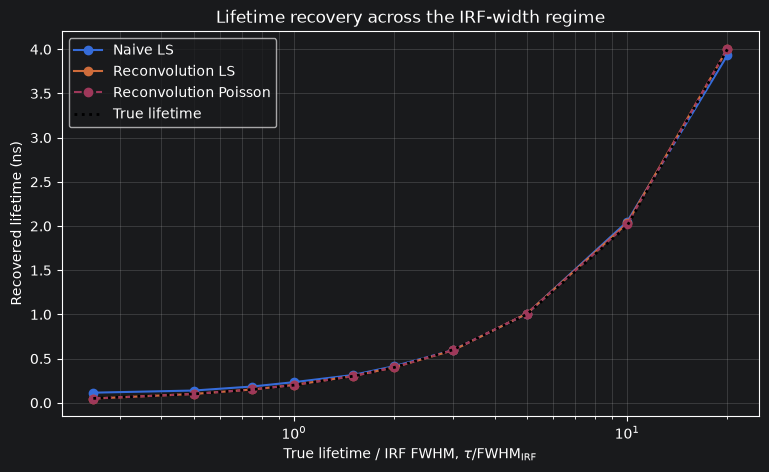

In [38]:
plt.figure(figsize=(9, 5))

plt.plot(
    sweep_comparison[
        "tau_over_fwhm"
    ],
    sweep_comparison[
        "tau_naive_ns"
    ],
    "o-",
    label="Naive LS",
)

plt.plot(
    sweep_comparison[
        "tau_over_fwhm"
    ],
    sweep_comparison[
        "tau_reconv_ls_ns"
    ],
    "o-",
    label="Reconvolution LS",
)

plt.plot(
    sweep_comparison[
        "tau_over_fwhm"
    ],
    sweep_comparison[
        "tau_reconv_poisson_ns"
    ],
    "o--",
    label="Reconvolution Poisson",
)

plt.plot(
    sweep_comparison[
        "tau_over_fwhm"
    ],
    sweep_comparison[
        "tau_true_ns"
    ],
    "k:",
    linewidth=2,
    label="True lifetime",
)

plt.xscale("log")

plt.xlabel(
    r"True lifetime / IRF FWHM, "
    r"$\tau/\mathrm{FWHM}_{\mathrm{IRF}}$"
)
plt.ylabel("Recovered lifetime (ns)")
plt.title(
    "Lifetime recovery across the IRF-width regime"
)
plt.legend()
plt.grid(
    alpha=0.3,
    which="both",
)

plt.show()

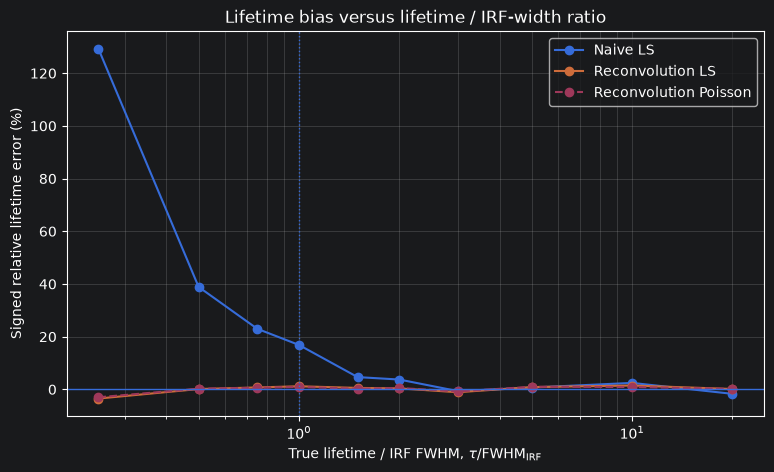

In [39]:
plt.figure(figsize=(9, 5))

plt.plot(
    sweep_comparison[
        "tau_over_fwhm"
    ],
    sweep_comparison[
        "naive_error_percent"
    ],
    "o-",
    label="Naive LS",
)

plt.plot(
    sweep_comparison[
        "tau_over_fwhm"
    ],
    sweep_comparison[
        "reconv_ls_error_percent"
    ],
    "o-",
    label="Reconvolution LS",
)

plt.plot(
    sweep_comparison[
        "tau_over_fwhm"
    ],
    sweep_comparison[
        "reconv_poisson_error_percent"
    ],
    "o--",
    label="Reconvolution Poisson",
)

plt.axhline(
    0.0,
    linewidth=1,
)

plt.axvline(
    1.0,
    linestyle=":",
    linewidth=1,
)

plt.xscale("log")

plt.xlabel(
    r"True lifetime / IRF FWHM, "
    r"$\tau/\mathrm{FWHM}_{\mathrm{IRF}}$"
)
plt.ylabel("Signed relative lifetime error (%)")
plt.title(
    "Lifetime bias versus lifetime / IRF-width ratio"
)
plt.legend()
plt.grid(
    alpha=0.3,
    which="both",
)

plt.show()

### Interpretation

The naive unconvolved fit becomes increasingly biased as the fluorescence
lifetime approaches the temporal width of the instrument response.

For lifetimes much longer than the IRF width, the instrumental broadening is
relatively unimportant and the naive fit provides a reasonable approximation.
However, when

$$
\tau \sim \mathrm{FWHM}_{\mathrm{IRF}},
$$

the measured leading edge is strongly shaped by the IRF and the unconvolved
exponential systematically overestimates the lifetime. The bias becomes very
large when

$$
\tau < \mathrm{FWHM}_{\mathrm{IRF}}.
$$

Both reconvolution approaches largely remove this systematic bias because they
fit the measured histogram through the complete forward model

$$
\mu(t)
=
A
\left[
\mathrm{IRF}_{\Delta t} * I_{\tau}
\right](t)
+
B.
$$

In the present high-count regime, least-squares and Poisson maximum-likelihood
reconvolution yield very similar lifetime estimates. This is expected because
Poisson counting fluctuations become increasingly Gaussian-like at high photon
counts.

The principal improvement in this experiment therefore comes from using the
correct reconvolution model rather than from changing the statistical objective.

## Monte Carlo photon-count experiment

The previous sweep demonstrated that the dominant systematic error arises from
ignoring the IRF.

We now focus only on the two reconvolution approaches and ask a different
question:

> How does the choice between least squares and Poisson maximum likelihood
> affect lifetime recovery as the number of detected photons decreases?

A challenging lifetime is selected:

$$
\frac{\tau}{\mathrm{FWHM}_{\mathrm{IRF}}}
=
0.5,
$$

corresponding to

$$
\tau = 0.1\ \mathrm{ns}
$$

for the present $0.2$ ns IRF.

At this lifetime, the measured histogram is strongly shaped by the instrument
response, but the preceding high-count experiment showed that reconvolution can
still recover the lifetime accurately.

For every photon-count level, many independent Poisson realizations of the same
underlying decay are generated and fitted using:

1. least-squares reconvolution;
2. Poisson maximum-likelihood reconvolution.

The total expected detector background is scaled together with the fluorescence
signal so that the approximate signal-to-background ratio remains constant.
This isolates the effect of photon-counting statistics from a simultaneous
change in measurement background.

In [40]:
monte_carlo_tau_over_fwhm = 0.5

monte_carlo_lifetime = (
    monte_carlo_tau_over_fwhm
    * irf_fwhm
)

photon_levels = np.array([
    100,
    300,
    1_000,
    3_000,
    10_000,
    100_000,
])

n_repetitions = 50

In [41]:
reference_signal_photons = 100_000
reference_background = 2.0

background_per_signal_photon = (
    reference_background
    / reference_signal_photons
)

In [42]:
monte_carlo_conditions = pd.DataFrame(
    {
        "Signal photons": photon_levels,
        "Background (counts/bin)": (
            photon_levels
            * background_per_signal_photon
        ),
    }
)

print(
    f"Monte Carlo lifetime: "
    f"{monte_carlo_lifetime:.3f} ns"
)

print(
    "Lifetime / IRF FWHM: "
    f"{monte_carlo_tau_over_fwhm:.2f}"
)

print(
    f"Repetitions per photon level: "
    f"{n_repetitions}"
)

monte_carlo_conditions

Monte Carlo lifetime: 0.100 ns
Lifetime / IRF FWHM: 0.50
Repetitions per photon level: 50


,Signal photons,Background (counts/bin)
0,100,0.002
1,300,0.006
2,1000,0.020
3,3000,0.060
4,10000,0.200
5,100000,2.000


Only reconvolution fitting is compared in this experiment.

The naive exponential is no longer included because its structural bias has
already been demonstrated. In addition, using a noisy naive lifetime estimate
as the reconvolution starting point would introduce another source of
photon-count-dependent variation.

Instead, both reconvolution fits use a simple data-derived amplitude and
background estimate together with a fixed lifetime starting value based on the
known IRF time scale.

The Poisson fit is initialized from the least-squares reconvolution solution.
The experiment therefore compares the statistical objectives rather than
optimizer robustness.

In [43]:
def fit_reconvolution_pair(
    target_signal_photons: int,
    rng: np.random.Generator,
) -> dict[str, float | bool]:
    unit_decay = monoexponential_decay(
        time=time,
        amplitude=1.0,
        lifetime=monte_carlo_lifetime,
        background=0.0,
    )

    unit_convolved = (
        convolve_decay_with_irf(
            time=time,
            decay=unit_decay,
            irf=irf,
        )
    )

    true_amplitude = (
        target_signal_photons
        / unit_convolved.sum()
    )

    true_background = (
        target_signal_photons
        * background_per_signal_photon
    )

    expected_counts = (
        true_amplitude * unit_convolved
        + true_background
    )

    measured_counts = sample_photon_counts(
        expected_counts=expected_counts,
        rng=rng,
    )

    # Low-count background estimate:
    # use the mean rather than the median because
    # the median is often exactly zero.
    background_guess = max(
        float(
            np.mean(
                measured_counts[-100:]
            )
        ),
        1e-6,
    )

    estimated_signal_counts = max(
        float(measured_counts.sum())
        - background_guess
        * measured_counts.size,
        1.0,
    )

    # Use the IRF width as a generic lifetime guess.
    initial_lifetime = irf_fwhm

    initial_decay = monoexponential_decay(
        time=time,
        amplitude=1.0,
        lifetime=initial_lifetime,
        background=0.0,
    )

    initial_convolved = (
        convolve_decay_with_irf(
            time=time,
            decay=initial_decay,
            irf=irf,
        )
    )

    amplitude_guess = (
        estimated_signal_counts
        / initial_convolved.sum()
    )

    least_squares_result = (
        fit_monoexponential_reconvolution(
            time=time,
            counts=measured_counts,
            irf=irf,
            initial_guess=(
                amplitude_guess,
                initial_lifetime,
                background_guess,
                0.0,
            ),
            temporal_shift_bounds=(
                -0.5,
                0.5,
            ),
            objective="least_squares",
        )
    )

    poisson_background_guess = max(
        least_squares_result.background,
        1e-6,
    )

    poisson_result = (
        fit_monoexponential_reconvolution(
            time=time,
            counts=measured_counts,
            irf=irf,
            initial_guess=(
                least_squares_result.amplitude,
                least_squares_result.lifetime,
                poisson_background_guess,
                least_squares_result.temporal_shift,
            ),
            temporal_shift_bounds=(
                -0.5,
                0.5,
            ),
            objective="poisson",
        )
    )

    least_squares_relative_error = (
        least_squares_result.lifetime
        - monte_carlo_lifetime
    ) / monte_carlo_lifetime

    poisson_relative_error = (
        poisson_result.lifetime
        - monte_carlo_lifetime
    ) / monte_carlo_lifetime

    return {
        "target_signal_photons": (
            target_signal_photons
        ),
        "true_background": true_background,
        "least_squares_lifetime": (
            least_squares_result.lifetime
        ),
        "poisson_lifetime": (
            poisson_result.lifetime
        ),
        "least_squares_relative_error": (
            least_squares_relative_error
        ),
        "poisson_relative_error": (
            poisson_relative_error
        ),
        "least_squares_shift": (
            least_squares_result.temporal_shift
        ),
        "poisson_shift": (
            poisson_result.temporal_shift
        ),
        "least_squares_success": (
            least_squares_result.success
        ),
        "poisson_success": (
            poisson_result.success
        ),
    }

In [44]:
test_rng = np.random.default_rng(42)

test_results = []

for photon_count in photon_levels:
    print(
        f"Fitting {photon_count} signal photons..."
    )

    result = fit_reconvolution_pair(
        target_signal_photons=int(
            photon_count
        ),
        rng=test_rng,
    )

    test_results.append(result)

Fitting 100 signal photons...
Fitting 300 signal photons...
Fitting 1000 signal photons...
Fitting 3000 signal photons...
Fitting 10000 signal photons...
Fitting 100000 signal photons...


In [45]:
test_table = pd.DataFrame(
    [
        {
            "Signal photons": result[
                "target_signal_photons"
            ],
            "LS lifetime (ns)": result[
                "least_squares_lifetime"
            ],
            "Poisson lifetime (ns)": result[
                "poisson_lifetime"
            ],
            "LS error (%)": (
                100
                * result[
                    "least_squares_relative_error"
                ]
            ),
            "Poisson error (%)": (
                100
                * result[
                    "poisson_relative_error"
                ]
            ),
            "LS shift (ns)": result[
                "least_squares_shift"
            ],
            "Poisson shift (ns)": result[
                "poisson_shift"
            ],
            "LS success": result[
                "least_squares_success"
            ],
            "Poisson success": result[
                "poisson_success"
            ],
        }
        for result in test_results
    ]
)

test_table

,Signal photons,LS lifetime (ns),Poisson lifetime (ns),LS error (%),Poisson error (%),LS shift (ns),Poisson shift (ns),LS success,Poisson success
0,100,0.052016,0.076013,-47.984241,-23.986630,0.036323,0.023916,True,True
1,300,0.100157,0.092612,0.156627,-7.388225,-0.000651,0.003599,True,True
2,1000,0.109247,0.109594,9.246747,9.594225,-0.009998,-0.006851,True,True
3,3000,0.092441,0.093033,-7.558791,-6.967399,0.002520,0.004422,True,True
4,10000,0.101654,0.100647,1.653513,0.646862,-0.000758,-0.000352,True,True
5,100000,0.101258,0.100759,1.257811,0.759435,-0.001067,-0.000448,True,True


In [46]:
monte_carlo_rng = np.random.default_rng(
    12345
)

monte_carlo_results = []

for photon_count in photon_levels:
    for repetition in range(
        n_repetitions
    ):
        result = fit_reconvolution_pair(
            target_signal_photons=int(
                photon_count
            ),
            rng=monte_carlo_rng,
        )

        result["repetition"] = repetition

        monte_carlo_results.append(
            result
        )

In [47]:
monte_carlo_data = pd.DataFrame(
    monte_carlo_results
)

monte_carlo_data.head()

,target_signal_photons,true_background,least_squares_lifetime,poisson_lifetime,least_squares_relative_error,poisson_relative_error,least_squares_shift,poisson_shift,least_squares_success,poisson_success,repetition
0,100,0.002,0.018045,0.019338,-0.819548,-0.806621,0.062103,0.064460,True,True,0
1,100,0.002,0.065911,0.074934,-0.340887,-0.250663,0.028049,0.012187,True,True,1
2,100,0.002,0.103342,0.115277,0.033416,0.152767,0.021399,0.010119,True,True,2
3,100,0.002,0.124855,0.109155,0.248547,0.091549,-0.015679,-0.007458,True,True,3
4,100,0.002,0.126788,0.143854,0.267881,0.438537,-0.018507,-0.021946,True,True,4


In [48]:
success_summary = (
    monte_carlo_data
    .groupby(
        "target_signal_photons"
    )
    .agg(
        LS_success_rate=(
            "least_squares_success",
            "mean",
        ),
        Poisson_success_rate=(
            "poisson_success",
            "mean",
        ),
    )
)

success_summary

,LS_success_rate,Poisson_success_rate
target_signal_photons,,
100,1.0,1.0
300,1.0,1.0
1000,1.0,1.0
3000,1.0,1.0
10000,1.0,1.0
100000,1.0,1.0


In [49]:
summary_rows = []

for photon_count in photon_levels:
    subset = monte_carlo_data[
        monte_carlo_data[
            "target_signal_photons"
        ]
        == photon_count
    ]

    for method, column in [
        (
            "Reconvolution LS",
            "least_squares_relative_error",
        ),
        (
            "Reconvolution Poisson",
            "poisson_relative_error",
        ),
    ]:
        errors = (
            100
            * subset[column].to_numpy()
        )

        summary_rows.append(
            {
                "Signal photons": (
                    photon_count
                ),
                "Method": method,
                "Bias (%)": (
                    np.mean(errors)
                ),
                "Median absolute error (%)": (
                    np.median(
                        np.abs(errors)
                    )
                ),
                "RMSE (%)": (
                    np.sqrt(
                        np.mean(
                            errors**2
                        )
                    )
                ),
                "Std. dev. (%)": (
                    np.std(
                        errors,
                        ddof=1,
                    )
                ),
            }
        )

monte_carlo_summary = pd.DataFrame(
    summary_rows
)

monte_carlo_summary

,Signal photons,Method,Bias (%),Median absolute error (%),RMSE (%),Std. dev. (%)
0,100,Reconvolution LS,-9.057898,20.182233,38.569445,37.871379
1,100,Reconvolution Poisson,-8.107409,11.002440,31.391031,30.633894
2,300,Reconvolution LS,1.472927,14.622946,18.943233,19.077622
3,300,Reconvolution Poisson,4.837332,8.305039,11.225807,10.232948
4,1000,Reconvolution LS,-2.832474,5.689644,9.763586,9.438561
5,1000,Reconvolution Poisson,-0.873245,4.505506,6.479875,6.485952
6,3000,Reconvolution LS,0.615966,4.128150,5.757929,5.783010
7,3000,Reconvolution Poisson,0.413151,3.563603,4.432664,4.458175
8,10000,Reconvolution LS,-0.116006,2.010842,2.524280,2.547214
9,10000,Reconvolution Poisson,-0.085135,1.561321,2.096803,2.116344


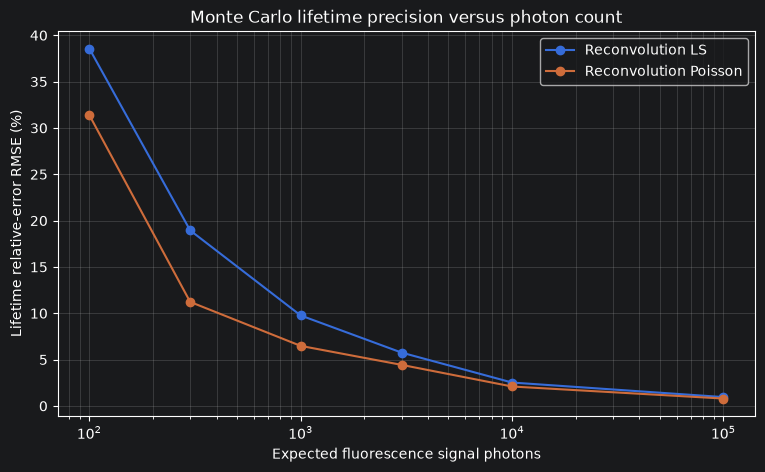

In [50]:
plt.figure(figsize=(9, 5))

for method in [
    "Reconvolution LS",
    "Reconvolution Poisson",
]:
    subset = monte_carlo_summary[
        monte_carlo_summary[
            "Method"
        ]
        == method
    ]

    plt.plot(
        subset["Signal photons"],
        subset["RMSE (%)"],
        "o-",
        label=method,
    )

plt.xscale("log")

plt.xlabel("Expected fluorescence signal photons")
plt.ylabel("Lifetime relative-error RMSE (%)")
plt.title(
    "Monte Carlo lifetime precision versus photon count"
)
plt.legend()
plt.grid(
    alpha=0.3,
    which="both",
)

plt.show()

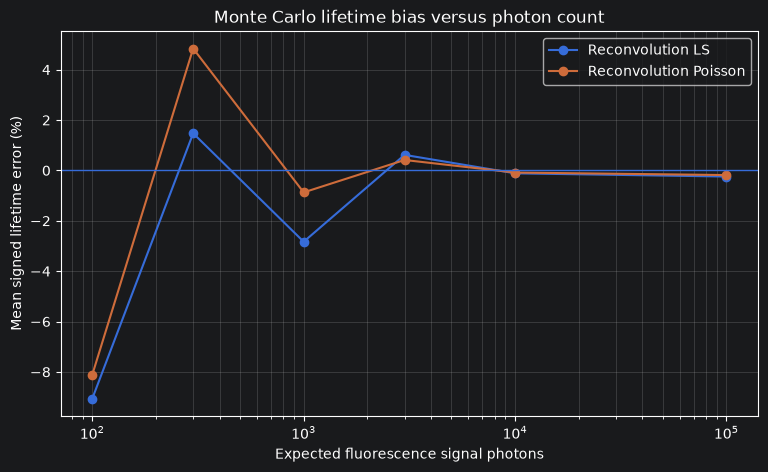

In [51]:
plt.figure(figsize=(9, 5))

for method in [
    "Reconvolution LS",
    "Reconvolution Poisson",
]:
    subset = monte_carlo_summary[
        monte_carlo_summary[
            "Method"
        ]
        == method
    ]

    plt.plot(
        subset["Signal photons"],
        subset["Bias (%)"],
        "o-",
        label=method,
    )

plt.axhline(
    0.0,
    linewidth=1,
)

plt.xscale("log")

plt.xlabel("Expected fluorescence signal photons")
plt.ylabel("Mean signed lifetime error (%)")
plt.title(
    "Monte Carlo lifetime bias versus photon count"
)
plt.legend()
plt.grid(
    alpha=0.3,
    which="both",
)

plt.show()

In [52]:
rmse_comparison = (
    monte_carlo_summary
    .pivot(
        index="Signal photons",
        columns="Method",
        values="RMSE (%)",
    )
    .reset_index()
)

rmse_comparison[
    "Poisson RMSE reduction (%)"
] = (
    100
    * (
        rmse_comparison[
            "Reconvolution LS"
        ]
        - rmse_comparison[
            "Reconvolution Poisson"
        ]
    )
    / rmse_comparison[
        "Reconvolution LS"
    ]
)

rmse_comparison

Method,Signal photons,Reconvolution LS,Reconvolution Poisson,Poisson RMSE reduction (%)
0,100,38.569445,31.391031,18.611659
1,300,18.943233,11.225807,40.739752
2,1000,9.763586,6.479875,33.632225
3,3000,5.757929,4.432664,23.016352
4,10000,2.524280,2.096803,16.934639
5,100000,0.954766,0.796352,16.591948


The relative RMSE reduction makes the statistical benefit of Poisson fitting
more explicit.

A value of zero indicates equivalent lifetime precision, while positive values
indicate lower Monte Carlo RMSE for the Poisson-MLE estimator.

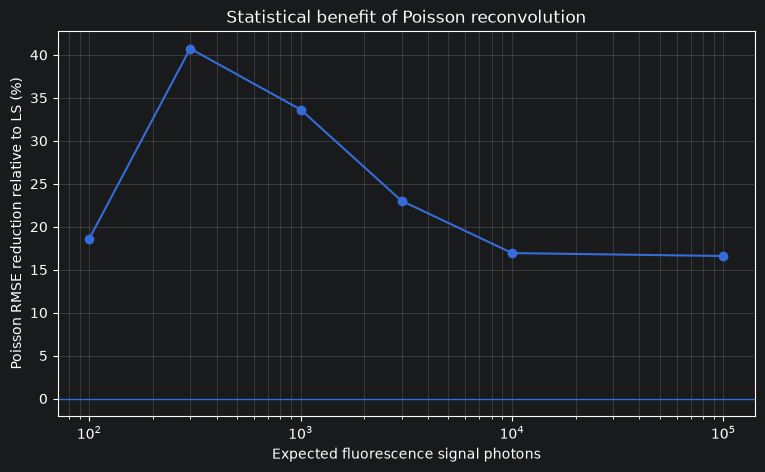

In [53]:
plt.figure(figsize=(9, 5))

plt.plot(
    rmse_comparison[
        "Signal photons"
    ],
    rmse_comparison[
        "Poisson RMSE reduction (%)"
    ],
    "o-",
)

plt.axhline(
    0.0,
    linewidth=1,
)

plt.xscale("log")

plt.xlabel(
    "Expected fluorescence signal photons"
)
plt.ylabel(
    "Poisson RMSE reduction relative to LS (%)"
)
plt.title(
    "Statistical benefit of Poisson reconvolution"
)

plt.grid(
    alpha=0.3,
    which="both",
)

plt.show()

In [54]:
selected_photon_levels = [
    100,
    1_000,
    100_000,
]

distribution_rows = []

for photon_count in selected_photon_levels:
    subset = monte_carlo_data[
        monte_carlo_data[
            "target_signal_photons"
        ]
        == photon_count
    ]

    for error in (
        100
        * subset[
            "least_squares_relative_error"
        ].to_numpy()
    ):
        distribution_rows.append(
            {
                "Signal photons": photon_count,
                "Method": "Reconvolution LS",
                "Lifetime error (%)": error,
            }
        )

    for error in (
        100
        * subset[
            "poisson_relative_error"
        ].to_numpy()
    ):
        distribution_rows.append(
            {
                "Signal photons": photon_count,
                "Method": (
                    "Reconvolution Poisson"
                ),
                "Lifetime error (%)": error,
            }
        )

distribution_data = pd.DataFrame(
    distribution_rows
)

In [55]:
boxplot_data = []
boxplot_positions = []
boxplot_labels = []

position = 1

for photon_count in selected_photon_levels:
    for method in [
        "Reconvolution LS",
        "Reconvolution Poisson",
    ]:
        values = distribution_data[
            (
                distribution_data[
                    "Signal photons"
                ]
                == photon_count
            )
            & (
                distribution_data[
                    "Method"
                ]
                == method
            )
        ][
            "Lifetime error (%)"
        ].to_numpy()

        boxplot_data.append(values)
        boxplot_positions.append(position)

        if method == "Reconvolution LS":
            boxplot_labels.append(
                f"{photon_count}\nLS"
            )
        else:
            boxplot_labels.append(
                f"{photon_count}\nPoisson"
            )

        position += 1

    position += 1

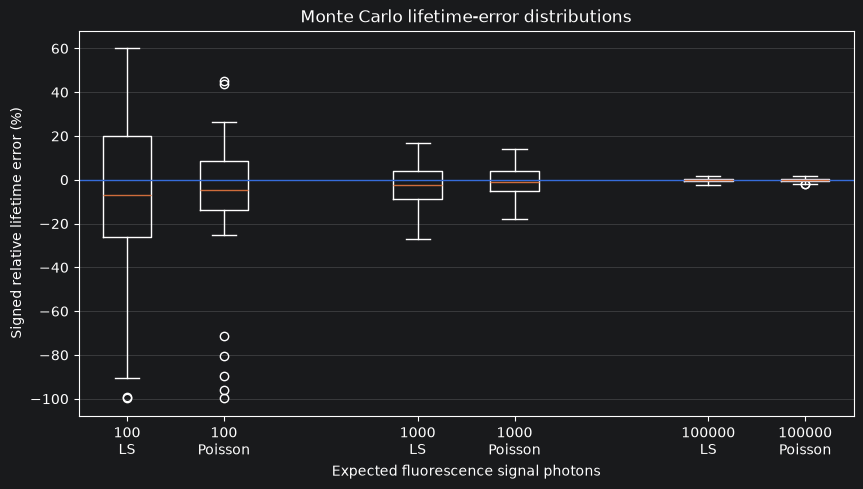

In [56]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    boxplot_data,
    positions=boxplot_positions,
)

plt.axhline(
    0.0,
    linewidth=1,
)

plt.xticks(
    boxplot_positions,
    boxplot_labels,
)

plt.xlabel(
    "Expected fluorescence signal photons"
)
plt.ylabel(
    "Signed relative lifetime error (%)"
)
plt.title(
    "Monte Carlo lifetime-error distributions"
)

plt.grid(
    alpha=0.3,
    axis="y",
)

plt.show()

In [57]:
shift_summary_rows = []

for photon_count in photon_levels:
    subset = monte_carlo_data[
        monte_carlo_data[
            "target_signal_photons"
        ]
        == photon_count
    ]

    for method, column in [
        (
            "Reconvolution LS",
            "least_squares_shift",
        ),
        (
            "Reconvolution Poisson",
            "poisson_shift",
        ),
    ]:
        shifts = subset[
            column
        ].to_numpy()

        shift_summary_rows.append(
            {
                "Signal photons": (
                    photon_count
                ),
                "Method": method,
                "Mean shift (ns)": (
                    np.mean(shifts)
                ),
                "Shift std. dev. (ns)": (
                    np.std(
                        shifts,
                        ddof=1,
                    )
                ),
            }
        )

shift_summary = pd.DataFrame(
    shift_summary_rows
)

shift_summary

,Signal photons,Method,Mean shift (ns),Shift std. dev. (ns)
0,100,Reconvolution LS,0.006037,0.028135
1,100,Reconvolution Poisson,0.006521,0.025580
2,300,Reconvolution LS,0.000109,0.014487
3,300,Reconvolution Poisson,-0.002042,0.009503
4,1000,Reconvolution LS,0.001516,0.007317
5,1000,Reconvolution Poisson,0.000699,0.005374
6,3000,Reconvolution LS,0.000138,0.003752
7,3000,Reconvolution Poisson,0.000193,0.003240
8,10000,Reconvolution LS,-0.000069,0.001983
9,10000,Reconvolution Poisson,0.000008,0.001661


### Interpretation of the photon-count experiment

The Monte Carlo experiment reveals a different effect from the previous
lifetime/IRF-width sweep.

Both fitting approaches use the same physical reconvolution model, so the
systematic error associated with ignoring the IRF has already been removed.
The remaining difference comes from the statistical objective.

At high photon counts, least-squares and Poisson reconvolution give very
similar lifetime precision. This is consistent with the fact that a Poisson
distribution with a large expectation becomes increasingly well approximated
by a Gaussian distribution.

As the photon count decreases, however, the heteroscedastic nature of the
Poisson data becomes increasingly important:

$$
\operatorname{Var}(N_i)=\mu_i.
$$

Ordinary unweighted least squares treats deviations in every histogram bin
equally, despite their different statistical variances.

Poisson maximum likelihood instead evaluates each bin using the photon-counting
probability model itself. In the present Monte Carlo experiment this produces a
lower lifetime-error RMSE, particularly in the low- and intermediate-count
regimes.

The signed-bias results remain relatively close to zero compared with the
width of the error distributions. The improvement from Poisson fitting is
therefore primarily a reduction in statistical uncertainty rather than the
removal of a large systematic lifetime bias.

At very low photon numbers, both estimators become substantially less precise.
This reflects a genuine information limit of the measurement rather than a
failure of reconvolution fitting.

## Physical-model error versus statistical error

The two systematic experiments in this notebook address different limitations
of TCSPC lifetime analysis.

### Ignoring the IRF

When the lifetime approaches the IRF width, an unconvolved exponential is no
longer an adequate model of the measured histogram.

This produces a systematic lifetime bias:

$$
\tau_{\mathrm{fit}}
\neq
\tau_{\mathrm{true}}.
$$

Reconvolution largely removes this error by fitting the complete measurement
model.

### Ignoring Poisson counting statistics

Once the correct reconvolution model is used, ordinary least squares can still
provide accurate results when photon counts are high.

At lower photon counts, however, the variance of the measured histogram is
strongly count dependent:

$$
\operatorname{Var}(N_i)=\mu_i.
$$

Poisson maximum likelihood incorporates this statistical structure directly
and provides better lifetime precision in the low-count regime.

The two improvements therefore solve different problems:

$$
\boxed{
\text{reconvolution}
\rightarrow
\text{correct physical forward model}
}
$$

and

$$
\boxed{
\text{Poisson MLE}
\rightarrow
\text{correct photon-counting statistics}
}.
$$

## Conclusions

This notebook completes the mono-exponential reconvolution workflow developed
during Week 4.

The main results are:

- a realistic TCSPC histogram can be generated from an ideal fluorescence
  decay, a known normalized IRF, detector background, and Poisson photon
  sampling;

- fitting the decay tail with an unconvolved exponential produces systematic
  lifetime bias when the fluorescence lifetime becomes comparable to or
  shorter than the IRF width;

- least-squares reconvolution accurately recovers lifetime and temporal
  alignment by fitting the complete TCSPC forward model;

- Poisson maximum-likelihood reconvolution uses the same physical model but
  replaces the least-squares objective with the appropriate photon-counting
  likelihood;

- raw residuals reveal absolute model discrepancies, while Poisson deviance
  residuals provide a statistically scaled diagnostic across the large dynamic
  range of a TCSPC histogram;

- in the high-count regime, least-squares and Poisson reconvolution give nearly
  identical parameter estimates;

- Monte Carlo simulations show that the statistical advantage of Poisson
  maximum likelihood becomes increasingly important as the photon count is
  reduced;

- neither reconvolution nor Poisson likelihood removes the fundamental loss of
  information that occurs when very short lifetimes are measured with limited
  photon statistics and a finite-width IRF.

The resulting analysis pipeline is

$$
\text{ideal decay}
\rightarrow
\text{IRF reconvolution}
\rightarrow
\text{Poisson measurement}
\rightarrow
\text{parameter estimation}
\rightarrow
\text{Poisson-aware diagnostics}.
$$

With the IRF shape treated as known, the toolkit can therefore recover

$$
(A,\tau,B,\Delta t)
$$

directly from synthetic TCSPC photon-counting data using either
least-squares or Poisson maximum-likelihood reconvolution.